# Cricket Image Classification Notebook

This notebook trains a simple baseline classifier from the existing folder labels in `dataset/raw`:
- `male_cricket`
- `female_cricket`
- `dead_cricket`

It loads images from the folder structure, visualizes samples, trains a lightweight model, and saves the result.

In [10]:
from pathlib import Path
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

DATA_DIR = Path("dataset/raw")
CLASSES = ["male_cricket", "female_cricket", "dead_cricket"]
IMAGE_SIZE = (32, 32)
RANDOM_STATE = 42
MODEL_PATH = Path("cricket_classifier.pkl")

print("Data directory:", DATA_DIR.resolve())
print("Classes:", CLASSES)

Data directory: D:\work\AcridideaPi\AI\dataset\raw
Classes: ['male_cricket', 'female_cricket', 'dead_cricket']


## Load the Dataset

Read the image files from the class folders and build a list of paths plus labels.

In [ ]:
records = []
for label in CLASSES:
    class_dir = DATA_DIR / label
    if not class_dir.exists():
        print(f"Missing folder: {class_dir}")
        continue
    for image_path in sorted(class_dir.glob("*")):
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
            records.append((image_path, label))

print(f"Found {len(records)} images total")
for label in CLASSES:
    count = sum(1 for _, item_label in records if item_label == label)
    print(f"{label}: {count}")

if not records:
    raise ValueError("No images were found. Make sure dataset/raw contains the class folders and images.")

Found 301 images total
male_cricket: 37
female_cricket: 231
dead_cricket: 33


## Visualize Sample Images

Show a few random images from each class so you can confirm the dataset looks correct.

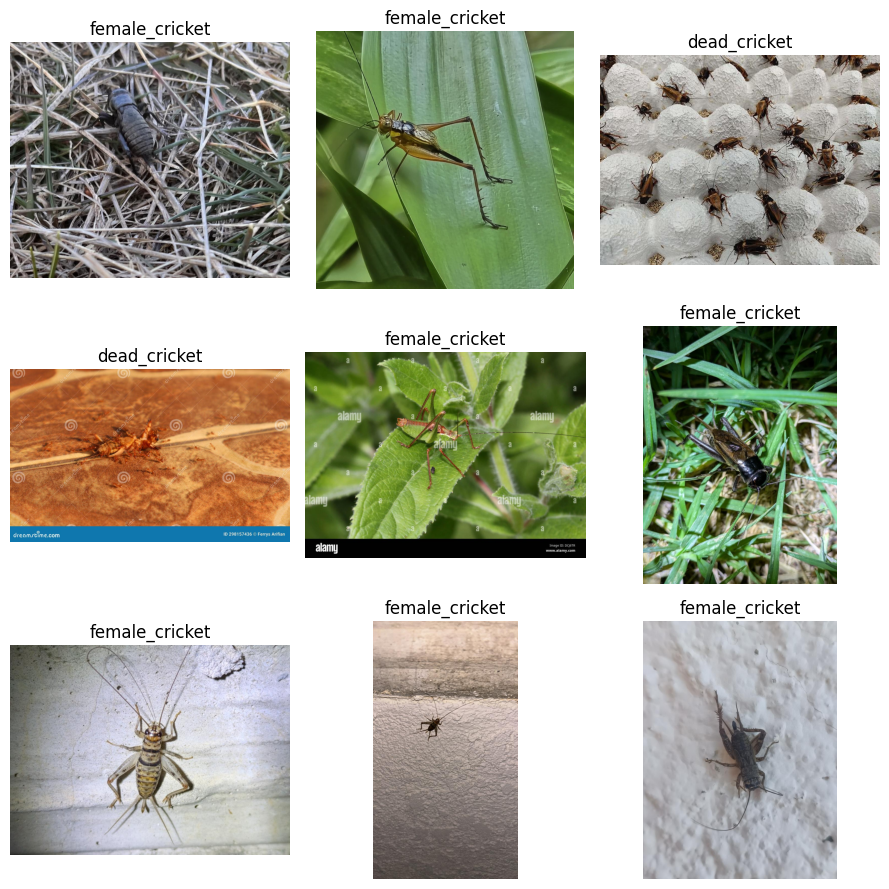

In [3]:
sample_count = min(9, len(records))
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes_list = list(axes.flat)
for axis, (image_path, label) in zip(axes_list, random.sample(records, sample_count)):
    image = Image.open(image_path).convert("RGB")
    axis.imshow(image)
    axis.set_title(label)
    axis.axis("off")

for axis in axes_list[sample_count:]:
    axis.axis("off")

plt.tight_layout()
plt.show()

## Train the Model

Balance the training split by oversampling the minority classes, then train a logistic regression baseline.

In [8]:
from collections import Counter

def load_image(path):
    image = Image.open(path).convert("RGB").resize(IMAGE_SIZE)
    return np.asarray(image, dtype=np.float32) / 255.0


def oversample_training_data(X_train, y_train, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    class_counts = Counter(y_train)
    target_size = max(class_counts.values())
    balanced_indices = []

    for class_name in sorted(class_counts):
        class_indices = np.where(y_train == class_name)[0]
        sampled_indices = rng.choice(class_indices, size=target_size, replace=True)
        balanced_indices.append(sampled_indices)

    balanced_indices = np.concatenate(balanced_indices)
    rng.shuffle(balanced_indices)
    return X_train[balanced_indices], y_train[balanced_indices]


X = np.stack([load_image(image_path).reshape(-1) for image_path, _ in records])
y = np.array([label for _, label in records])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train_balanced, y_train_balanced = oversample_training_data(X_train, y_train)
model = LogisticRegression(max_iter=2000)
model.fit(X_train_balanced, y_train_balanced)

print("Training samples:", len(X_train))
print("Balanced training samples:", len(X_train_balanced))
print("Test samples:", len(X_test))
print("Training class counts before balance:", dict(Counter(y_train)))
print("Training class counts after balance:", dict(Counter(y_train_balanced)))

Training samples: 240
Balanced training samples: 552
Test samples: 61
Training class counts before balance: {np.str_('female_cricket'): 184, np.str_('male_cricket'): 30, np.str_('dead_cricket'): 26}
Training class counts after balance: {np.str_('dead_cricket'): 184, np.str_('female_cricket'): 184, np.str_('male_cricket'): 184}


## Evaluate and Save

Measure accuracy, inspect the confusion matrix, and save the trained model to disk.

Accuracy: 0.754

                precision    recall  f1-score   support

  dead_cricket       0.20      0.14      0.17         7
female_cricket       0.85      0.87      0.86        47
  male_cricket       0.50      0.57      0.53         7

      accuracy                           0.75        61
     macro avg       0.52      0.53      0.52        61
  weighted avg       0.74      0.75      0.75        61



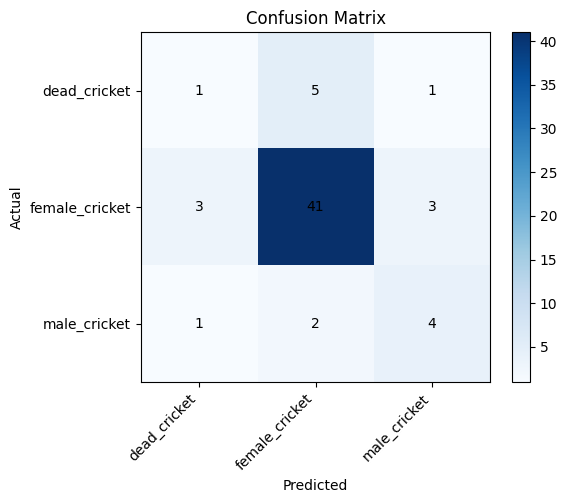

Saved model to D:\work\AcridideaPi\AI\cricket_classifier.pkl
Example prediction for male_cricket_0000.jpg: male_cricket (0.75)


In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print()
print(classification_report(y_test, y_pred))

labels_sorted = sorted(CLASSES)
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_sorted)))
ax.set_yticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
ax.set_yticklabels(labels_sorted)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        ax.text(col_index, row_index, cm[row_index, col_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

with open(MODEL_PATH, "wb") as model_file:
    pickle.dump({"model": model, "image_size": IMAGE_SIZE, "classes": CLASSES}, model_file)

print(f"Saved model to {MODEL_PATH.resolve()}")


def predict_image(image_path):
    image_vector = load_image(image_path).reshape(1, -1)
    prediction = model.predict(image_vector)[0]
    probabilities = model.predict_proba(image_vector)[0]
    best_index = int(np.argmax(probabilities))
    return prediction, probabilities[best_index]

example_path = records[0][0]
predicted_label, confidence = predict_image(example_path)
print(f"Example prediction for {example_path.name}: {predicted_label} ({confidence:.2f})")